In [33]:
from dotenv import load_dotenv

load_dotenv()

True

In [34]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [35]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [36]:
from langgraph.prebuilt import ToolNode

tool_list = [add,multiply]
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode([add, multiply])

In [37]:
ai_message = llm_with_tools.invoke("What is 3 plus 5")

In [38]:
tool_node.invoke({'messages':[ai_message]})

{'messages': [ToolMessage(content='8', name='add', tool_call_id='call_UcHHi4LK2HoUfZJPqs1DOMKP')]}

In [39]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [40]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [41]:
def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return 'end'

In [42]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [43]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    {
        'tools': 'tools',
        'end': END
    }
)
graph_builder.add_edge('tools','agent')

In [44]:
graph = graph_builder.compile()

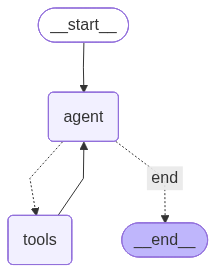

In [45]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
    from langchain_core.messages import HumanMessage

    for chunk in graph.stream({'messages': [HumanMessage('3에다 5를 더하고 거기에 8을 곱하면?')]}, stream_mode='values'):
        chunk['messages'][-1].pretty_print()

================================ Human Message =================================

3에다 5를 더하고 거기에 8을 곱하면?
================================== Ai Message ==================================
Tool Calls:
  add (call_OMn4xlNAZYKZPD7ZlAaye7vF)
 Call ID: call_OMn4xlNAZYKZPD7ZlAaye7vF
  Args:
    a: 3
    b: 5
  multiply (call_BxbOaf2suFOkcUhBNhexC0yt)
 Call ID: call_BxbOaf2suFOkcUhBNhexC0yt
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: multiply

40
================================== Ai Message ==================================
Tool Calls:
  multiply (call_vUbvFHI6QZtdZ7ONPPx36vwV)
 Call ID: call_vUbvFHI6QZtdZ7ONPPx36vwV
  Args:
    a: 8
    b: 8
================================= Tool Message =================================
Name: multiply

64
================================== Ai Message ==================================

3에 5를 더하면 8이 되고, 그 결과에 8을 곱하면 64가 됩니다.
